In [1]:
# ============================================
# RANDOM FOREST - RIVERBANK EROSION PREDICTION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# ============================================
# 1. LOAD PREPROCESSED DATA
# ============================================

X_train = pd.read_csv("../data/processed/X_train_processed.csv")
X_test = pd.read_csv("../data/processed/X_test_processed.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

Training data shape: (4000, 12)
Testing data shape: (2000, 12)

Training labels:
Label
0    2000
1    2000
Name: count, dtype: int64

Testing labels:
Label
0    1000
1    1000
Name: count, dtype: int64


In [3]:
# ============================================
# 2. CREATE RANDOM FOREST MODEL
# ============================================

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [4]:
# ============================================
# 3. TRAIN MODEL
# ============================================

print("\nTraining Random Forest...")

model.fit(X_train, y_train)

print("Training completed.")


Training Random Forest...
Training completed.


In [5]:
# ============================================
# 4. MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

# Probability of class 1
y_prob = model.predict_proba(X_test)[:, 1]

In [6]:
# ============================================
# 5. CALCULATE PERFORMANCE METRICS
# ============================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

In [7]:
# ============================================
# 6. DISPLAY RESULTS
# ============================================

print("\n============================================")
print("RANDOM FOREST RESULTS")
print("============================================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


RANDOM FOREST RESULTS
Accuracy  : 0.9865
Precision : 0.9812
Recall    : 0.9920
F1-Score  : 0.9866
ROC-AUC   : 0.9939


In [8]:
# ============================================
# 7. CLASSIFICATION REPORT
# ============================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Stable",
            "Potential Erosion"
        ],
        zero_division=0
    )
)


Classification Report:
                   precision    recall  f1-score   support

           Stable       0.99      0.98      0.99      1000
Potential Erosion       0.98      0.99      0.99      1000

         accuracy                           0.99      2000
        macro avg       0.99      0.99      0.99      2000
     weighted avg       0.99      0.99      0.99      2000



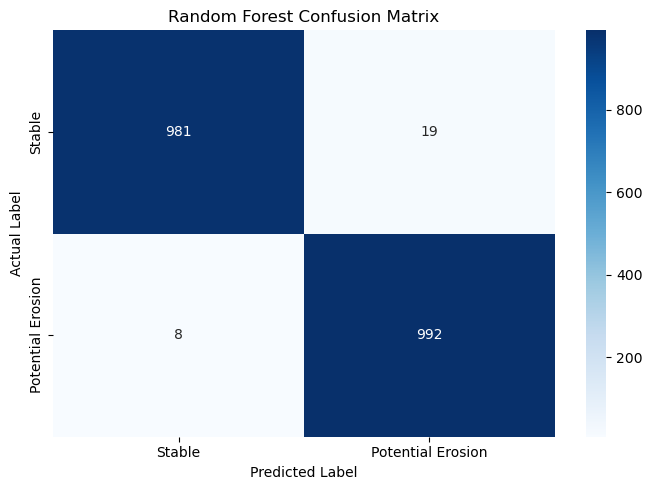

In [9]:
# ============================================
# 8. CONFUSION MATRIX
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Stable",
        "Potential Erosion"
    ],
    yticklabels=[
        "Stable",
        "Potential Erosion"
    ]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()


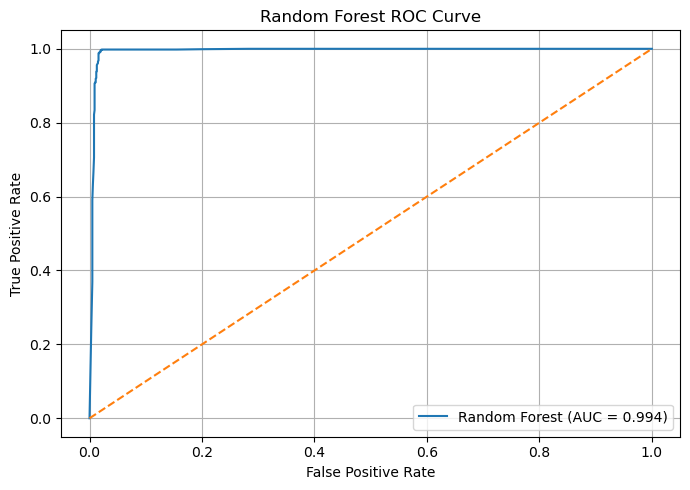

In [10]:
# ============================================
# 9. ROC CURVE
# ============================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC Curve")

plt.legend()

plt.grid()

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# 10. FEATURE IMPORTANCE
# ============================================

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
                         Feature  Importance
4   numeric__Distance_From_River    0.453566
1                  numeric__NDWI    0.170623
5       categorical__LandCover_0    0.168101
0                  numeric__NDVI    0.091191
2             numeric__Elevation    0.047771
3              numeric__Rainfall    0.022805
6       categorical__LandCover_1    0.021476
8       categorical__LandCover_4    0.014981
10      categorical__LandCover_6    0.004819
9       categorical__LandCover_5    0.003282
7       categorical__LandCover_3    0.001281
11      categorical__LandCover_7    0.000104


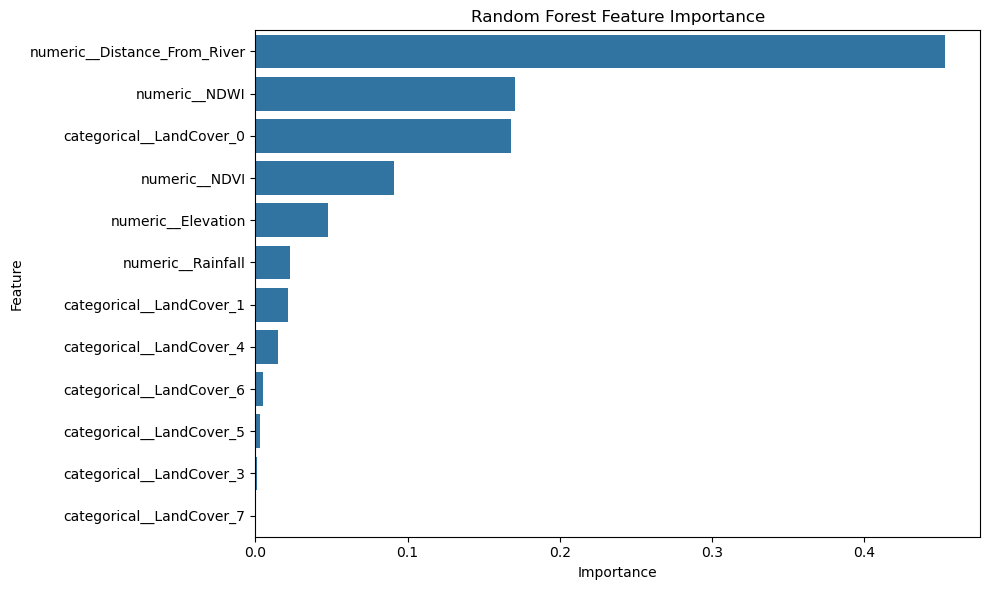

In [12]:
# ============================================
# 11. FEATURE IMPORTANCE PLOT
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# 12. SAVE FEATURE IMPORTANCE
# ============================================

feature_importance.to_csv(
    "../results/random_forest_feature_importance.csv",
    index=False
)

In [14]:
# ============================================
# 13. SAVE MODEL RESULTS
# ============================================

results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1_Score": [f1],
    "ROC_AUC": [roc_auc]
})

results.to_csv(
    "../results/random_forest_results.csv",
    index=False
)

In [15]:
# ============================================
# 14. SAVE PREDICTIONS
# ============================================

predictions = pd.DataFrame({
    "Actual_Label": y_test,
    "Predicted_Label": y_pred,
    "Probability_Potential_Erosion": y_prob
})

predictions.to_csv(
    "../results/random_forest_predictions.csv",
    index=False
)

In [16]:
# ============================================
# 15. SAVE MODEL
# ============================================

joblib.dump(
    model,
    "../models/random_forest_model.pkl"
)

print("\n============================================")
print("FILES SAVED SUCCESSFULLY")
print("============================================")

print("Model:")
print("../models/random_forest_model.pkl")

print("\nResults:")
print("../results/random_forest_results.csv")

print("\nFeature importance:")
print("../results/random_forest_feature_importance.csv")

print("\nPredictions:")
print("../results/random_forest_predictions.csv")


FILES SAVED SUCCESSFULLY
Model:
../models/random_forest_model.pkl

Results:
../results/random_forest_results.csv

Feature importance:
../results/random_forest_feature_importance.csv

Predictions:
../results/random_forest_predictions.csv
